In [ ]:
import pandas as pd
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingClassifier

In [37]:
df = pd.read_csv('train.csv')

In [ ]:
df.head()

,label,f0,f1,f2,f3,f4,f5,f6,f7,f8,...,f18,f19,f20,f21,f22,f23,f24,f25,f26,f27
0,1.0,0.869293,-0.635082,0.225690,0.327470,-0.689993,0.754202,-0.248573,-1.092064,0.000000,...,-0.010455,-0.045767,3.101961,1.353760,0.979563,0.978076,0.920005,0.721657,0.988751,0.876678
1,1.0,0.907542,0.329147,0.359412,1.497970,-0.313010,1.095531,-0.557525,-1.588230,2.173076,...,-1.138930,-0.000819,0.000000,0.302220,0.833048,0.985700,0.978098,0.779732,0.992356,0.798343
2,1.0,0.798835,1.470639,-1.635975,0.453773,0.425629,1.104875,1.282322,1.381664,0.000000,...,1.128848,0.900461,0.000000,0.909753,1.108330,0.985692,0.951331,0.803252,0.865924,0.780118
3,0.0,1.344385,-0.876626,0.935913,1.992050,0.882454,1.786066,-1.646778,-0.942383,0.000000,...,-0.678379,-1.360356,0.000000,0.946652,1.028704,0.998656,0.728281,0.869200,1.026736,0.957904
4,1.0,1.105009,0.321356,1.522401,0.882808,-1.205349,0.681466,-1.070464,-0.921871,0.000000,...,-0.373566,0.113041,0.000000,0.755856,1.361057,0.986610,0.838085,1.133295,0.872245,0.808487


In [38]:
df.drop(columns=['f7', 'f19'], inplace=True)
df.drop_duplicates(inplace=True)

In [39]:
X_train, X_test, y_train, y_test = train_test_split(df.iloc[:,1:], df.iloc[:, 0], random_state=42, test_size=0.2)

Accuracy without any preprocessing: 65.53%

In [57]:
classifier = GradientBoostingClassifier(max_depth = 8, min_samples_leaf=100, n_estimators=100)

In [58]:
classifier.fit(X_train, y_train)

GradientBoostingClassifier(max_depth=8, min_samples_leaf=100)

In [59]:
y_pred = classifier.predict(X_test)

In [60]:
accuracy_score(y_test, y_pred)

0.7228722872287229

In [61]:
classification_report(y_test, y_pred)

'              precision    recall  f1-score   support\n\n         0.0       0.71      0.69      0.70      4700\n         1.0       0.73      0.75      0.74      5299\n\n    accuracy                           0.72      9999\n   macro avg       0.72      0.72      0.72      9999\nweighted avg       0.72      0.72      0.72      9999\n'

In [ ]:
df.describe()

,label,f0,f1,f2,f3,f4,f5,f6,f8,f9,...,f17,f18,f20,f21,f22,f23,f24,f25,f26,f27
count,49994.000000,49994.000000,49994.000000,49994.000000,49994.000000,49994.000000,49994.000000,49994.000000,49994.000000,49994.000000,...,49994.000000,49994.000000,49994.000000,49994.000000,49994.000000,49994.000000,49994.000000,49994.000000,49994.000000,49994.000000
mean,0.531364,0.991170,-0.006799,-0.000688,0.993819,-0.008540,0.987551,-0.006263,0.995475,0.991737,...,0.987208,-0.005408,0.986852,1.031895,1.022117,1.050027,1.011173,0.974157,1.032047,0.958785
std,0.499020,0.564857,1.007313,1.008869,0.595414,1.006577,0.471291,1.011121,1.026846,0.498559,...,0.507457,1.010696,1.393152,0.648328,0.368613,0.162828,0.399956,0.525342,0.361801,0.311873
min,0.000000,0.274697,-2.434976,-1.742508,0.003158,-1.743944,0.139976,-2.968735,0.000000,0.188981,...,0.365354,-2.497265,0.000000,0.125548,0.342015,0.266788,0.319854,0.066392,0.303350,0.350939
25%,0.000000,0.592950,-0.745140,-0.871931,0.572076,-0.881635,0.677367,-0.696157,0.000000,0.658633,...,0.617281,-0.721686,0.000000,0.790766,0.846135,0.985769,0.768112,0.674548,0.819974,0.769669
50%,1.000000,0.855385,-0.009794,0.005410,0.888525,-0.013465,0.893216,-0.002006,1.086538,0.889508,...,0.872128,-0.007956,0.000000,0.894860,0.950145,0.989748,0.917482,0.874707,0.947113,0.870908
75%,1.000000,1.234534,0.732370,0.873213,1.291964,0.863706,1.169984,0.687194,2.173076,1.199986,...,1.221600,0.714102,3.101961,1.025413,1.082497,1.019583,1.141701,1.141269,1.137233,1.058374
max,1.000000,7.000281,2.431946,1.743236,6.582300,1.743102,7.064657,2.969674,2.173076,8.280169,...,7.512032,2.498009,3.101961,16.601603,8.940148,3.931808,7.442589,11.994177,6.401313,4.835312


In [ ]:
df_dummy = df[['f21', 'f22', 'f23', 'f24','f25','f26', 'label']]

<Axes: >

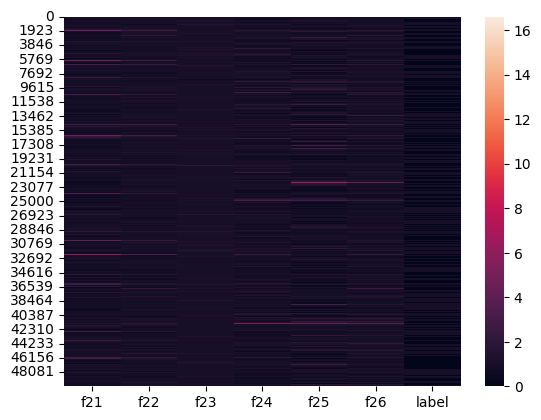

In [ ]:
sns.heatmap(df_dummy)

In [ ]:
df.corr()["label"].sort_values(ascending=False)

,label
label,1.000000
f5,0.049687
f17,0.038107
f22,0.025607
f9,0.020267
f20,0.019515
f13,0.018010
f23,0.013978
f21,0.011881
f15,0.005867


In [ ]:
df['label'].value_counts()

,count
label,
1.0,26565
0.0,23429
